In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('../data/csv/users_data.csv')
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   user_id               100000 non-null  int64  
 1   days_since_signup     100000 non-null  int64  
 2   sessions_last_7_days  100000 non-null  int64  
 3   avg_session_duration  100000 non-null  float64
 4   budgets_created       100000 non-null  int64  
 5   pdfs_downloaded       100000 non-null  int64  
 6   clients_added         100000 non-null  int64  
 7   sector                100000 non-null  str    
 8   converted_to_pro      100000 non-null  int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 6.9 MB


C:\Users\Jorge\AppData\Local\Temp\ipykernel_3060\2616342087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='converted_to_pro', data=df, palette='magma')


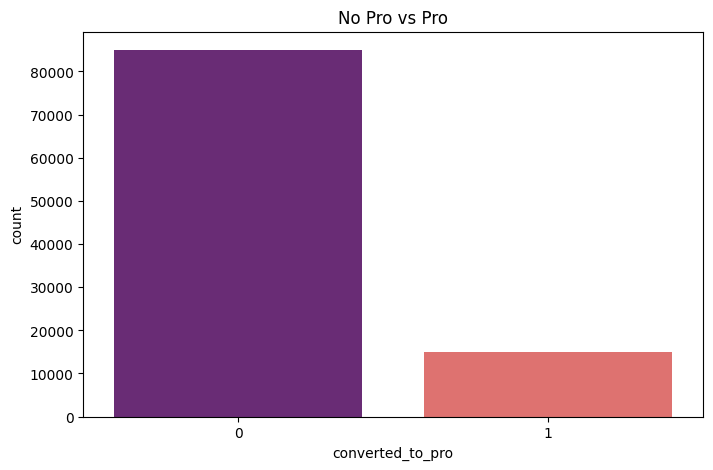

Diff:
converted_to_pro
0    85000
1    15000
Name: count, dtype: int64


In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='converted_to_pro', data=df, palette='magma')
plt.title('No Pro vs Pro')
plt.show()

counts = df['converted_to_pro'].value_counts()
percentages = df['converted_to_pro'].value_counts(normalize=True) * 100

print(f"Diff:\n{counts}")
 

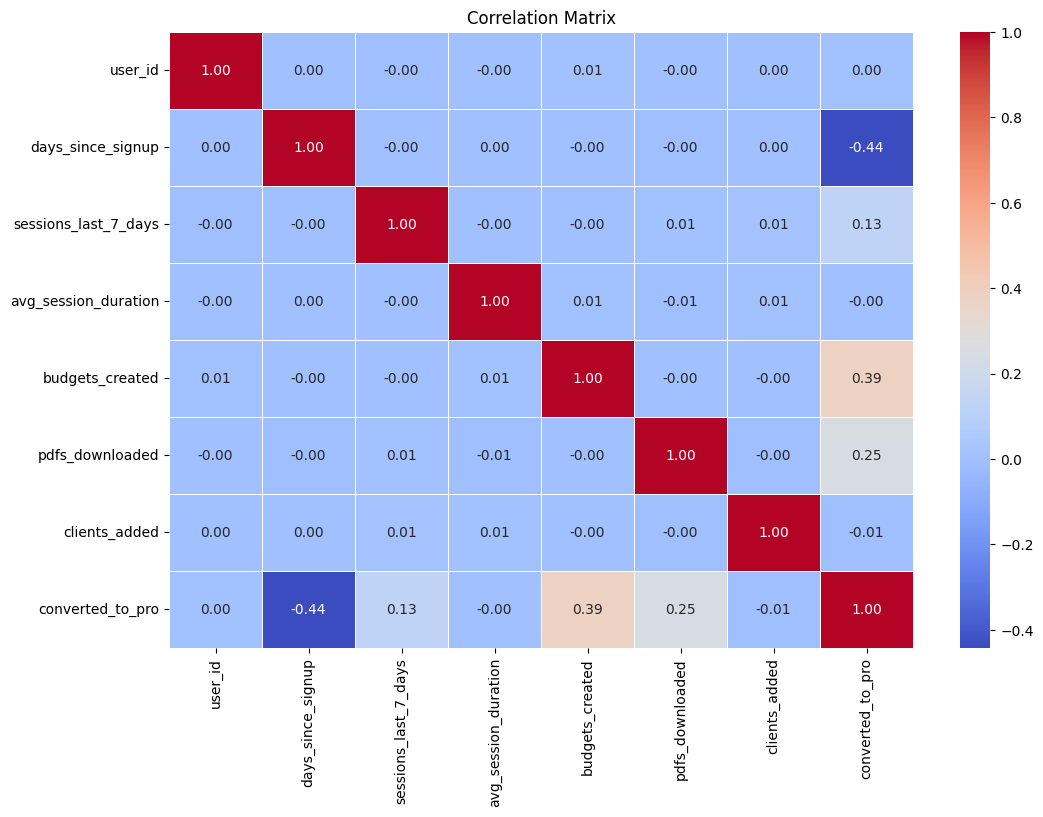

Target Correlation:
converted_to_pro        1.000000
budgets_created         0.385440
pdfs_downloaded         0.249427
sessions_last_7_days    0.127422
user_id                 0.003975
avg_session_duration   -0.000714
clients_added          -0.005045
days_since_signup      -0.442544
Name: converted_to_pro, dtype: float64


In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

target_corr = correlation_matrix['converted_to_pro'].sort_values(ascending=False)
print("Target Correlation:")
print(target_corr)

C:\Users\Jorge\AppData\Local\Temp\ipykernel_3060\3916791696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_conversion.index, y=sector_conversion.values, palette='viridis')


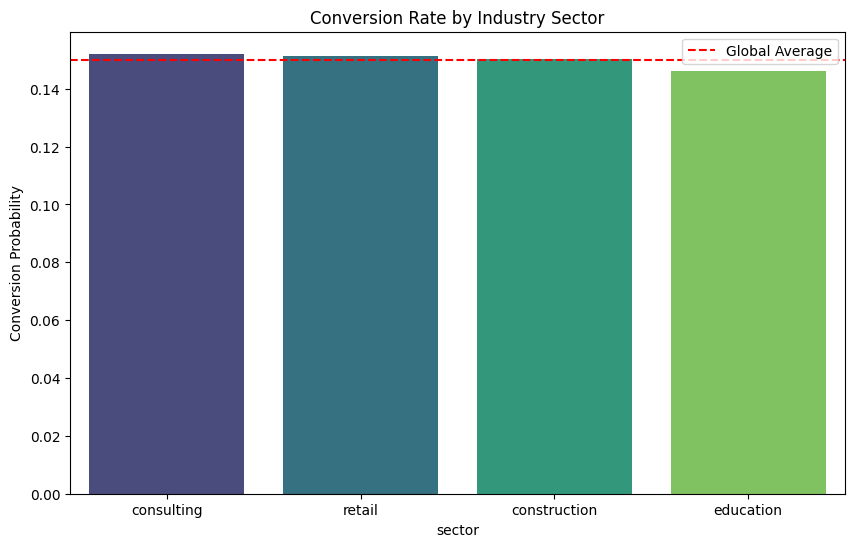

In [14]:
sector_conversion = df.groupby('sector')['converted_to_pro'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=sector_conversion.index, y=sector_conversion.values, palette='viridis')
plt.axhline(df['converted_to_pro'].mean(), color='red', linestyle='--', label='Global Average')
plt.title('Conversion Rate by Industry Sector')
plt.ylabel('Conversion Probability')
plt.legend()
plt.show()

In [16]:
null_values = df.isnull().sum()
variances = df.select_dtypes(include=['number']).var()

print("Checking Missing Values:")
print(null_values)
print("\nChecking Feature Variance:")
print(variances)

Checking Missing Values:
user_id                 0
days_since_signup       0
sessions_last_7_days    0
avg_session_duration    0
budgets_created         0
pdfs_downloaded         0
clients_added           0
sector                  0
converted_to_pro        0
dtype: int64

Checking Feature Variance:
user_id                 8.333417e+08
days_since_signup       1.105327e+04
sessions_last_7_days    2.080063e+02
avg_session_duration    7.264770e+01
budgets_created         8.356895e+02
pdfs_downloaded         1.329867e+02
clients_added           3.334910e+01
converted_to_pro        1.275013e-01
dtype: float64


In [23]:
import pandas as pd
import numpy as np

corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print("Columns to consider dropping (>0.90 correlation):")
print(to_drop)

extreme_pairs = []
for col in upper.columns:
    over_threshold = upper[col][upper[col] > 0.90]
    for index, value in over_threshold.items():
        extreme_pairs.append((index, col, value))

print("\nSpecific pairs and their correlation:")
for p in extreme_pairs:
    print(f"{p[0]} <-> {p[1]}: {p[2]:.4f}")

Columns to consider dropping (>0.90 correlation):
[]

Specific pairs and their correlation:


#  EDA: Observaciones y Conclusiones / Observations & Conclusions

---

### 🇪🇸 Castellano
* **Desequilibrio de Clases:** El **85% de los usuarios** no paga la versión Pro, lo que confirma un desbalanceo moderado en el dataset que afectará a la elección de métricas.
* **Correlaciones Detectadas:** * Relación **lineal inversa** con `days_since_signup` (a más antigüedad, menos probabilidad de conversión).
    * Relación **lineal positiva** con `budgets_created` y `pdfs_downloaded`.
* **Análisis Sectorial:** El sector de **Educación** es el que presenta la menor tasa de conversión a la versión Pro.
* **Ingeniería de Características (Hoja de Ruta):**
    * Se prescindirá de `user_id`: su varianza es equivalente al número de datos (es un ID único) y no aporta valor predictivo.
    * Debido a la disparidad de varianzas entre columnas, es obligatorio aplicar un **StandardScaler**.

---

### 🇺🇸 English
* **Class Imbalance:** **85% of users** do not upgrade to the Pro version, confirming a moderate class imbalance that dictates the use of specific evaluation metrics.
* **Correlation Insights:** * **Inverse linear relationship** with `days_since_signup` (older accounts are less likely to convert).
    * **Positive linear correlation** with `budgets_created` and `pdfs_downloaded`.
* **Sector Analysis:** The **Education** sector shows the lowest conversion rate to Pro.
* **Feature Engineering Roadmap:**
    * `user_id` will be dropped: its variance matches the record count (unique ID) and lacks predictive power.
    * Given the variance disparities across features, applying **StandardScaler** is a technical requirement.